# Empirical Battery SOH Degradation Modeling

### Project
Edge AI Smart Battery Management System

### Dataset
NASA Lithium-Ion Battery Dataset

### Objective
To investigate the relationship between battery State of Health (SOH)
and battery aging/cycle number, and to derive and evaluate empirical
mathematical degradation models.

### Research Question
Can the degradation of lithium-ion battery SOH be represented by
an empirical mathematical relationship derived from experimental data?

### Dataset
Cycle-level battery degradation dataset containing:
- Battery ID
- Cycle number
- Discharge capacity
- Voltage characteristics
- Current characteristics
- Temperature characteristics
- Discharge duration
- SOH
- RUL

## Objectives

1. Inspect and validate the battery degradation dataset.
2. Analyze SOH degradation across battery cycles.
3. Identify relationships between SOH and measurable battery parameters.
4. Develop candidate empirical degradation equations.
5. Estimate the parameters of each equation using experimental data.
6. Compare the models using MAE, RMSE and R².
7. Evaluate model generalization across different batteries.
8. Select the most suitable empirical model as a baseline for later
   machine-learning models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
DATA_PATH = "cycle_summary_soh_rul.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully.
Shape: (2524, 16)


,battery_id,cycle,capacity_Ah,max_voltage_V,min_voltage_V,mean_voltage_V,max_current_A,min_current_A,mean_current_A,max_temperature_C,min_temperature_C,mean_temperature_C,discharge_time_s,soh,rul,rated_capacity_Ah
0,B0005,1,1.856487,4.191492,2.612467,3.529829,0.000729,-2.018015,-1.818702,38.982181,24.325993,32.572328,3690.234,1.011587,167,1.835222
1,B0005,2,1.846327,4.189773,2.587209,3.537320,0.002927,-2.016821,-1.817560,39.033398,24.685948,32.725235,3672.344,1.006051,166,1.835222
2,B0005,3,1.835349,4.188187,2.651917,3.543737,0.001484,-2.016574,-1.816487,38.818797,24.734266,32.642862,3651.641,1.000069,165,1.835222
3,B0005,4,1.835263,4.188461,2.592948,3.543666,0.001547,-2.015936,-1.825589,38.762305,24.652244,32.514876,3631.563,1.000022,164,1.835222
4,B0005,5,1.834646,4.188299,2.547420,3.542343,0.001701,-2.017426,-1.826114,38.665393,24.518700,32.382349,3629.172,0.999686,163,1.835222


In [3]:
print("Columns:")
for column in df.columns:
    print(" -", column)

Columns:
 - battery_id
 - cycle
 - capacity_Ah
 - max_voltage_V
 - min_voltage_V
 - mean_voltage_V
 - max_current_A
 - min_current_A
 - mean_current_A
 - max_temperature_C
 - min_temperature_C
 - mean_temperature_C
 - discharge_time_s
 - soh
 - rul
 - rated_capacity_Ah


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2524 entries, 0 to 2523
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   battery_id          2524 non-null   object 
 1   cycle               2524 non-null   int64  
 2   capacity_Ah         2524 non-null   float64
 3   max_voltage_V       2524 non-null   float64
 4   min_voltage_V       2524 non-null   float64
 5   mean_voltage_V      2524 non-null   float64
 6   max_current_A       2524 non-null   float64
 7   min_current_A       2524 non-null   float64
 8   mean_current_A      2524 non-null   float64
 9   max_temperature_C   2524 non-null   float64
 10  min_temperature_C   2524 non-null   float64
 11  mean_temperature_C  2524 non-null   float64
 12  discharge_time_s    2524 non-null   float64
 13  soh                 2524 non-null   float64
 14  rul                 2524 non-null   int64  
 15  rated_capacity_Ah   2524 non-null   float64
dtypes: flo

In [5]:
display(df.describe())

,cycle,capacity_Ah,max_voltage_V,min_voltage_V,mean_voltage_V,max_current_A,min_current_A,mean_current_A,max_temperature_C,min_temperature_C,mean_temperature_C,discharge_time_s,soh,rul,rated_capacity_Ah
count,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000,2524.000000
mean,61.906101,1.437685,4.186738,2.323147,3.414459,0.001274,-2.350177,-1.766010,36.033870,20.513503,28.314431,3424.334013,0.887453,61.389461,1.619346
std,49.476333,0.304691,0.027364,0.285072,0.117043,0.002514,1.059682,0.689297,15.712064,11.914543,13.500430,1268.716037,0.107518,49.843545,0.278871
min,1.000000,0.556990,3.800033,1.193246,2.883240,-0.006740,-4.038796,-3.976473,10.149344,3.424939,7.677310,982.938000,0.321313,0.000000,0.850376
25%,22.000000,1.247929,4.182156,2.071378,3.367918,-0.000198,-3.977051,-1.939170,19.217126,5.960449,12.212004,2818.578000,0.829714,20.000000,1.476990
50%,47.000000,1.460954,4.187051,2.386750,3.412324,0.001155,-2.013328,-1.802806,38.303620,23.762265,31.852048,3066.766000,0.905728,48.000000,1.706159
75%,95.000000,1.693611,4.197671,2.627129,3.478143,0.002515,-1.993164,-1.568401,48.174335,24.803771,37.225487,3475.758000,0.967074,94.000000,1.822056
max,197.000000,2.444062,4.519252,2.699983,3.717995,0.030461,-0.996920,-0.572134,69.869746,45.448270,58.954811,6574.671000,1.815976,196.000000,1.968572


In [6]:
print("Missing values:")
display(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

Missing values:


battery_id            0
cycle                 0
capacity_Ah           0
max_voltage_V         0
min_voltage_V         0
mean_voltage_V        0
max_current_A         0
min_current_A         0
mean_current_A        0
max_temperature_C     0
min_temperature_C     0
mean_temperature_C    0
discharge_time_s      0
soh                   0
rul                   0
rated_capacity_Ah     0
dtype: int64

Duplicate rows: 0


In [7]:
print("Number of batteries:", df["battery_id"].nunique())

print("\nBattery IDs:")
print(sorted(df["battery_id"].unique()))

Number of batteries: 32

Battery IDs:
['B0005', 'B0006', 'B0007', 'B0018', 'B0025', 'B0026', 'B0027', 'B0028', 'B0029', 'B0030', 'B0031', 'B0032', 'B0033', 'B0034', 'B0036', 'B0038', 'B0039', 'B0040', 'B0041', 'B0042', 'B0043', 'B0044', 'B0045', 'B0046', 'B0047', 'B0048', 'B0049', 'B0051', 'B0053', 'B0054', 'B0055', 'B0056']


In [8]:
battery_counts = (
    df.groupby("battery_id")["cycle"]
      .agg(["count", "min", "max"])
      .sort_values("count", ascending=False)
)

display(battery_counts)

,count,min,max
battery_id,,,
B0036,197,1,197
B0034,197,1,197
B0033,188,2,197
B0005,168,1,168
B0007,168,1,168
B0006,168,1,168
B0018,132,1,132
B0055,102,1,102
B0054,102,1,102


In [9]:
print("SOH statistics:")

print("Minimum SOH :", df["soh"].min())
print("Maximum SOH :", df["soh"].max())
print("Mean SOH    :", df["soh"].mean())
print("Median SOH  :", df["soh"].median())

SOH statistics:
Minimum SOH : 0.3213131633159661
Maximum SOH : 1.81597614789334
Mean SOH    : 0.8874533937581992
Median SOH  : 0.9057279473891854


In [10]:
display(
    df.groupby("battery_id")["soh"]
      .agg(["min", "max", "mean"])
      .sort_index()
)

,min,max,mean
battery_id,,,
B0005,0.701524,1.011587,0.856846
B0006,0.586120,1.033916,0.785773
B0007,0.744664,1.005529,0.874388
B0018,0.736010,1.018083,0.854914
B0025,0.956567,1.000502,0.982930
B0026,0.763785,1.000793,0.978429
B0027,0.972793,1.002039,0.991914
B0028,0.952848,1.001427,0.982159
B0029,0.887594,1.015673,0.950324


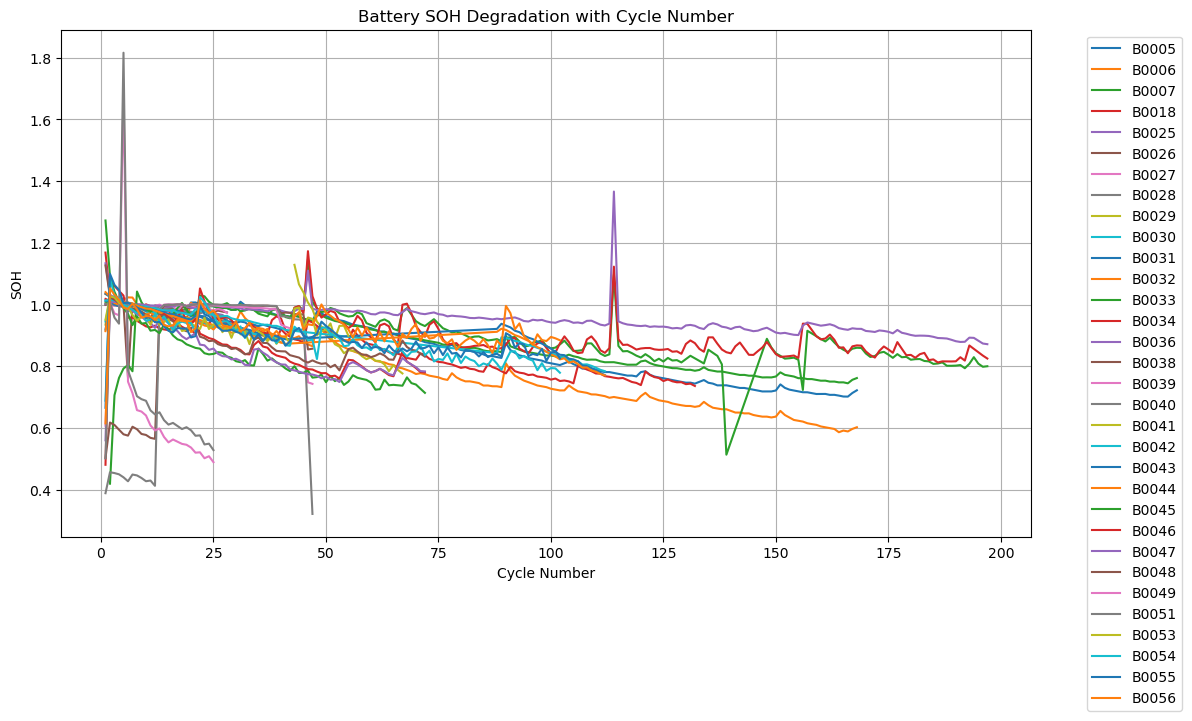

In [11]:
plt.figure(figsize=(12, 7))

for battery_id, battery_data in df.groupby("battery_id"):
    battery_data = battery_data.sort_values("cycle")
    
    plt.plot(
        battery_data["cycle"],
        battery_data["soh"],
        label=battery_id
    )

plt.xlabel("Cycle Number")
plt.ylabel("SOH")
plt.title("Battery SOH Degradation with Cycle Number")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

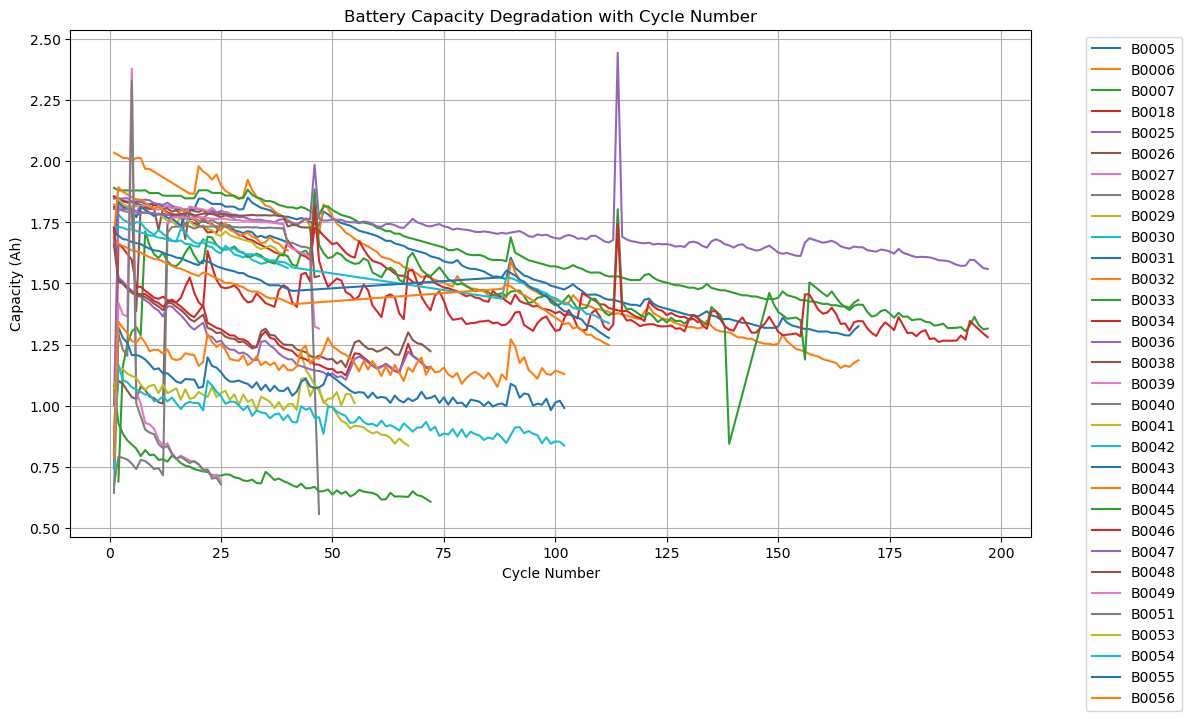

In [12]:
plt.figure(figsize=(12, 7))

for battery_id, battery_data in df.groupby("battery_id"):
    battery_data = battery_data.sort_values("cycle")
    
    plt.plot(
        battery_data["cycle"],
        battery_data["capacity_Ah"],
        label=battery_id
    )

plt.xlabel("Cycle Number")
plt.ylabel("Capacity (Ah)")
plt.title("Battery Capacity Degradation with Cycle Number")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [13]:
numeric_columns = [
    "cycle",
    "capacity_Ah",
    "max_voltage_V",
    "min_voltage_V",
    "mean_voltage_V",
    "max_current_A",
    "min_current_A",
    "mean_current_A",
    "max_temperature_C",
    "min_temperature_C",
    "mean_temperature_C",
    "discharge_time_s",
    "soh",
    "rul"
]

corr = df[numeric_columns].corr()

display(corr["soh"].sort_values(ascending=False))

soh                   1.000000
capacity_Ah           0.598001
rul                   0.370239
max_voltage_V         0.276190
discharge_time_s      0.257294
mean_voltage_V        0.237087
min_temperature_C     0.209148
mean_temperature_C    0.153671
max_temperature_C     0.104307
min_voltage_V        -0.001304
min_current_A        -0.074795
max_current_A        -0.091397
mean_current_A       -0.121072
cycle                -0.443923
Name: soh, dtype: float64